# Cats vs Dogs (Kaggle)

https://www.kaggle.com/c/dogs-vs-cats/

# Carregar imagens do diretório

In [1]:
import os
from itertools import batched

from IPython.core.pylabtools import figsize

current_dir = os.path.abspath(os.getcwd())
print(current_dir)

C:\Users\Nitro\PyCharmMiscProject\TensorFlow_Deep_Learning_Redes_Neurais\Convolucional


# Converter base de dados para treino, validação e teste

In [2]:
folder = "\\cats_and_dogs_dataset"
train_folder = current_dir + folder + "\\train"
val_folder = current_dir + folder + "\\validation"
test_folder = current_dir + folder + "\\test"

# Fazer o Tensorflow carregar as imagens para a RNA

In [3]:
import tensorflow as tf

print(tf.__version__)
print(tf.test.is_built_with_cuda())
print(tf.config.list_physical_devices('GPU'))

2.21.0
False
[]


In [5]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(train_folder, image_size=(180, 180),batch_size=32)

validation_dataset = image_dataset_from_directory(val_folder, image_size=(180,180), batch_size=32)

test_dataset = image_dataset_from_directory(test_folder, image_size=(180,180), batch_size=32)

Found 17538 files belonging to 2 classes.
Found 1219 files belonging to 2 classes.
Found 6243 files belonging to 2 classes.


In [6]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    print(data_batch[0].shape)
    break


data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)
(180, 180, 3)


# Exemplo de Data Augmentation

In [7]:
'''from matplotlib import pyplot as plt

def showSingleImage(img, title, size):
    fig, axis = plt.subplots(figsize = size)

    axis.imshow(img, 'gray')
    axis.set_title(title, fontdict = {})'''

"from matplotlib import pyplot as plt\n\ndef showSingleImage(img, title, size):\n    fig, axis = plt.subplots(figsize = size)\n\n    axis.imshow(img, 'gray')\n    axis.set_title(title, fontdict = {})"

# Treinando o modelo

In [6]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Rescaling

model = keras.Sequential()
model.add(Rescaling(scale=1.0/255))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

model.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        filepath = "model1.keras",
        save_best_only = True,
        monitor = "val_loss"
    )
]

history = model.fit(
    train_dataset,
    epochs = 30,
    validation_data = validation_dataset,
    callbacks = callbacks
)

Epoch 1/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 135s 243ms/step - accuracy: 0.6175 - loss: 0.7037 - val_accuracy: 0.7039 - val_loss: 0.5948
Epoch 2/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 132s 240ms/step - accuracy: 0.7148 - loss: 0.5584 - val_accuracy: 0.7063 - val_loss: 0.5952
Epoch 3/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 112s 205ms/step - accuracy: 0.7869 - loss: 0.4514 - val_accuracy: 0.7875 - val_loss: 0.4969
Epoch 4/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 111s 202ms/step - accuracy: 0.8533 - loss: 0.3364 - val_accuracy: 0.7875 - val_loss: 0.4968
Epoch 5/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 109s 199ms/step - accuracy: 0.9071 - loss: 0.2254 - val_accuracy: 0.7334 - val_loss: 0.7510
Epoch 6/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 99s 180ms/step - accuracy: 0.9493 - loss: 0.1393 - val_accuracy: 0.6612 - val_loss: 1.1343
Epoch 7/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 99s 181ms/step - accuracy: 0.9735 - loss: 0.0830 - val_accuracy: 0.7071 - val_loss: 1.2554
Epoch 8/30
549/549 ━━━━━━━━━━━━━━━━━━━━ 98s 179ms/step - accuracy: 0.9843 - lo

KeyboardInterrupt: 

In [ ]:
model.summary()

# Visualização de Resultados

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r", label="Treino acc")
plt.plot(epochs, val_accuracy, "b", label="Val acc")
plt.xlabel("Épocas")
plt.ylabel("%s")
plt.title("Acurácia de Treino e Validação")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r", label="Treino loss")
plt.plot(epochs, val_loss, "b", label="Val loss")
plt.xlabel("Épocas")
plt.ylabel("%s")
plt.title("Loss de Treino e Validação")
plt.legend()
plt.show()

# Resultados do Conjunto de Teste

In [ ]:
from tensorflow import keras
model = keras.models.load_model("model1.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

# Predição Imagem individual

In [8]:
from matplotlib import pyplot as plt

def showSingleImage(img, title, size):
    fig, axis = plt.subplots(figsize = size)

    axis.imshow(img, 'gray')
    axis.set_title(title, fontdict = {"fontsize" : 20, "fontweight" : "medium"})
    plt.show()

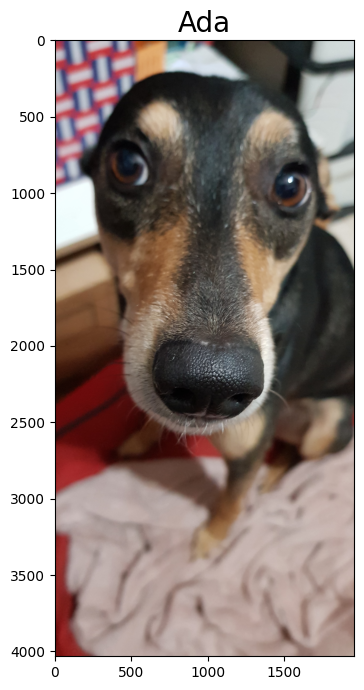

In [10]:
import cv2
ada_img = cv2.imread("ada.jpg")
ada_img = cv2.cvtColor(ada_img, cv2.COLOR_BGR2RGB)
#ada_img = cv2.resize(ada_img, (180,180), interpolation = cv2.INTER_AREA

showSingleImage(ada_img, "Ada", (12, 8))

In [ ]:
from keras.preprocessing import image
import numpy as np

ada_img = image.load_img("ada.jpg", target_size=(180,180))
x = image.img_to_array(ada_img)
x = np.expand_dims(x, axis=0)
pred = (model.predict(x) > 0.5).astype('int32')[0][0]

if pred == 1:
    print("cachorro")
else:
    print("Gato")

print(model.predict(x))